# Bayesian Optimization — Function 3 (3D, Improved)

This notebook runs one step of Bayesian Optimization on a **3-dimensional** black-box function.

### Improvements over the original F3 script

| Area | Original | Improved |
|---|---|---|
| **Seed** | None | `np.random.default_rng(42)` |
| **Data path** | Hardcoded Windows path | `pathlib.Path(".")` — portable |
| **Data loading** | Loads all 8 functions, uses only F3 | Loads F3 only |
| **y transform** | None | None needed (EI score healthy at 0.039) |
| **Kernel** | RBF | Matérn ν=2.5 |
| **xi** | Fixed at 0 (pure exploitation) | Adaptive (starts at 0.05, decays) |
| **Sampling** | 50k pure random | 30k Sobol quasi-random (tuned for 3D) |
| **L-BFGS-B starts** | 5 | 10 |
| **Acquisition** | EI only | EI or UCB (switchable) |
| **Structure** | One-shot script | Full BO loop with history tracking |
| **Visualization** | None | 2D slice plots (x₁–x₂, x₁–x₃, x₂–x₃) + convergence plot |

## 1. Imports & Configuration

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C, WhiteKernel
from scipy.stats import norm, qmc
from scipy.optimize import minimize

# ── SVM: Classify high vs low regions ────────────────────────────────────────
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# ── Neural Network: MC-Dropout surrogate ─────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim

import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
rng  = np.random.default_rng(SEED)
torch.manual_seed(SEED)

## 2. Data Loading

The original script loaded all 8 functions simultaneously but only used F3. This has been cleaned up to load F3 only.

F3 is **3-dimensional** (as seen from the 3-coordinate suggested point in the original output). The EI score of `~0.039` is healthy, indicating the GP has a reasonable model of the landscape — **no log-transform is needed** here.

In [2]:
# ── Portable data loading ─────────────────────────────────────────────────────
# Place initial_inputs.npy / initial_outputs.npy next to this notebook,
# OR change DATA_DIR to wherever the F3 data lives.
DATA_DIR = Path("C:\\Users\\fakep\\OneDrive\\Bureau\\CAPSTONE\\function_3\\")    # <-- edit if needed

X = np.load(DATA_DIR / "initial_inputs.npy")
y = np.load(DATA_DIR / "initial_outputs.npy")

n_dim = X.shape[1]
print(f"Loaded {len(y)} observations, {n_dim} dimensions.")
print(f"y range : [{y.min():.4f}, {y.max():.4f}]")
print(f"Current best y = {y.max():.6f}  (at index {y.argmax()})")

Loaded 15 observations, 3 dimensions.
y range : [-0.3989, -0.0348]
Current best y = -0.034835  (at index 3)


## 3. Gaussian Process Model

We use a **Matérn ν=2.5 kernel** instead of the original RBF:
- **RBF** assumes infinite differentiability — often an overly smooth assumption
- **Matérn 5/2** assumes only twice differentiability, which is more realistic for real-world black-box functions

In 3D with a limited number of initial observations, this flexibility matters more than in 2D — the GP needs to generalise across a larger volume with the same data.

In [3]:
def build_gp(n_dim: int) -> GaussianProcessRegressor:
    kernel = (
        C(1.0, constant_value_bounds=(1e-3, 1e5))
        * Matern(length_scale=[1.0] * n_dim,
                 length_scale_bounds=(1e-3, 1e3),
                 nu=2.5)
        + WhiteKernel(noise_level=1e-5,
                      noise_level_bounds=(1e-7, 1e-1))
    )
    return GaussianProcessRegressor(
        kernel=kernel,
        n_restarts_optimizer=25,
        alpha=1e-6,
        normalize_y=True,
    )

## 4. Acquisition Functions

Acquisition functions decide **where to sample next** by balancing exploration (uncertain regions) and exploitation (promising regions).

### Expected Improvement (EI)
$$EI(x) = (\mu(x) - y_{max} - \xi) \cdot \Phi(Z) + \sigma(x) \cdot \phi(Z), \quad Z = \frac{\mu(x) - y_{max} - \xi}{\sigma(x)}$$
where `ξ` (xi) controls the exploration-exploitation trade-off.

### Upper Confidence Bound (UCB)
$$UCB(x) = \mu(x) + \kappa \cdot \sigma(x)$$
where `κ` controls how much uncertainty is rewarded.

### Adaptive xi
The original F3 script used `xi=0` — pure exploitation. In 3D the search space is 8× larger than in 2D (unit cube volume stays 1, but the space is harder to cover), making exploration more important. We start at `xi_init=0.05` and decay over iterations.

In [4]:
def expected_improvement(X_cand, gp, y_max, xi=0.01):
    """Expected Improvement — higher is better."""
    X_cand = np.atleast_2d(X_cand)
    mu, sigma = gp.predict(X_cand, return_std=True)
    sigma = np.maximum(sigma, 1e-8)
    imp   = mu - y_max - xi
    Z     = imp / sigma
    ei    = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
    ei[sigma <= 1e-8] = 0.0
    return ei


def upper_confidence_bound(X_cand, gp, kappa=2.576):
    """UCB — higher kappa = more exploration."""
    X_cand = np.atleast_2d(X_cand)
    mu, sigma = gp.predict(X_cand, return_std=True)
    return mu + kappa * sigma


def adaptive_xi(iteration: int, xi_init=0.05, decay=0.85) -> float:
    """Decay xi over iterations for a smooth exploration → exploitation shift."""
    return max(xi_init * (decay ** iteration), 1e-4)

## 5. Next-Point Suggestion

We find the next point to evaluate in three steps:

1. **Sobol sampling** — generate `n_sobol` quasi-random candidates in [0,1]³. 30,000 points strikes the right balance for 3D: more uniform than 50k random samples from the original, while remaining computationally efficient.
2. **Score & rank** — evaluate the acquisition function on all candidates and keep the top `n_best`.
3. **Local optimisation** — run L-BFGS-B from each of the top `n_best` starting points and return the global winner. We use 10 restarts for 3D (more than 2D's 8, fewer than 8D's 15) to account for the slightly more complex acquisition landscape.

In [5]:
def suggest_next_point(
    gp,
    y_max,
    n_dim,
    xi=0.01,
    n_sobol=30_000,   # tuned for 3D
    n_best=10,        # more restarts than 2D, fewer than 8D
    acq="ei",
    kappa=2.576,
    seed=None,
):
    # Step 1 — Sobol candidates
    sampler = qmc.Sobol(d=n_dim, scramble=True, seed=seed)
    X_cand  = sampler.random(n_sobol)

    # Step 2 — Score
    if acq == "ucb":
        scores = upper_confidence_bound(X_cand, gp, kappa=kappa)
    else:
        scores = expected_improvement(X_cand, gp, y_max, xi=xi)

    # Step 3 — Local optimisation from top-n_best starts
    starts = X_cand[np.argsort(scores)[-n_best:]]
    bounds = [(0, 1)] * n_dim

    if acq == "ucb":
        obj = lambda x: -upper_confidence_bound(x, gp, kappa=kappa).item()
    else:
        obj = lambda x: -expected_improvement(x, gp, y_max, xi=xi).item()

    best_x, best_score = None, -np.inf
    for x0 in starts:
        res = minimize(obj, x0=x0, bounds=bounds, method="L-BFGS-B")
        if -res.fun > best_score:
            best_score = -res.fun
            best_x     = res.x

    return best_x, best_score

## 6. 3D Slice Visualisation Helper

A full 3D volume cannot be rendered as a single heatmap. Instead, we use **2D slice plots** — fixing one dimension at the value of the suggested next point and plotting the other two as a grid. This produces three panels:

- **x₁ – x₂ slice** (x₃ fixed at `x_next[2]`)
- **x₁ – x₃ slice** (x₂ fixed at `x_next[1]`)
- **x₂ – x₃ slice** (x₁ fixed at `x_next[0]`)

Each panel shows the **acquisition function** surface at that slice, with observed points projected onto the plane (those close to the fixed dimension's value are shown more opaquely). The suggested next point is marked with a red star at its 2D projection.

> Slicing at `x_next` is a natural choice: it shows the acquisition landscape around the most promising region the optimizer has identified.

In [6]:
def plot_slices_3d(gp, X_obs, x_next, acq_fn, iteration, acq_label="EI"):
    """
    3-panel slice plot of the acquisition function.
    Each panel fixes one dimension at x_next's value and sweeps the other two.
    """
    resolution = 150
    grid_1d    = np.linspace(0, 1, resolution)
    G1, G2     = np.meshgrid(grid_1d, grid_1d)
    flat       = G1.ravel()
    flat2      = G2.ravel()

    # Slice definitions: (x-axis dim, y-axis dim, fixed dim, fixed value, label)
    slices = [
        (0, 1, 2, x_next[2], "x₁", "x₂", f"x₃ = {x_next[2]:.3f}"),
        (0, 2, 1, x_next[1], "x₁", "x₃", f"x₂ = {x_next[1]:.3f}"),
        (1, 2, 0, x_next[0], "x₂", "x₃", f"x₁ = {x_next[0]:.3f}"),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(17, 5))
    fig.suptitle(
        f"Bayesian Optimization — F3  |  Iteration {iteration}  |  "
        f"Acquisition ({acq_label}) slices at x_next",
        fontsize=12
    )

    for ax, (d0, d1, d_fix, v_fix, xlabel, ylabel, fix_label) in zip(axes, slices):
        # Build grid with fixed dimension
        X_grid = np.zeros((resolution * resolution, 3))
        X_grid[:, d0]   = flat
        X_grid[:, d1]   = flat2
        X_grid[:, d_fix] = v_fix

        acq_vals = acq_fn(X_grid).reshape(resolution, resolution)

        im = ax.contourf(G1, G2, acq_vals, levels=50, cmap="inferno")
        fig.colorbar(im, ax=ax, shrink=0.85)

        # Project observed points (opacity scales with proximity to fixed dim value)
        dist    = np.abs(X_obs[:, d_fix] - v_fix)
        alphas  = np.clip(1.0 - dist / 0.3, 0.15, 1.0)
        for xi_obs, yi_obs, a in zip(X_obs[:, d0], X_obs[:, d1], alphas):
            ax.scatter(xi_obs, yi_obs, c="white", edgecolors="black",
                       s=40, alpha=float(a), zorder=5)

        # Suggested next point projection
        ax.scatter(x_next[d0], x_next[d1], c="red", marker="*",
                   s=250, zorder=6, label="Next point")

        ax.set_title(f"{xlabel}–{ylabel} slice  ({fix_label})")
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)

    axes[2].legend(loc="upper right", fontsize=8)
    plt.tight_layout()
    plt.savefig(f"bo_f3_iter_{iteration:03d}.png", dpi=150, bbox_inches="tight")
    plt.show()

## 7. Bayesian Optimization Loop

The full BO loop follows this cycle each iteration:

```
Fit GP  →  Compute xi  →  Maximise acquisition  →  Suggest x_next
         ↑                                                  |
         └──── Append (x_next, y_new) to dataset  ←────────┘
                   (you evaluate y_new externally)
```

**To use this loop:**
1. Run the cell — it will print the suggested point and render 3 slice plots
2. Evaluate the real function at `x_next` to get `y_new`
3. Uncomment the three lines under `PLUG YOUR EVALUATOR HERE`
4. Set `N_ITER > 1` and re-run for multi-step optimization

> **Note:** no log-transform is applied. Append the raw `y_new` value directly to `y_obs`.

C:\Users\fakep\AppData\Local\Temp\ipykernel_12296\2963030902.py:14: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X_cand  = sampler.random(n_sobol)



  Iteration   1  |  xi = 0.05000  |  acq = EI
  Current best y (log)          : -0.034835
  ✅ Suggested x CAPSTONE       : 0.225325-0.129253-0.0
  🎯 Suggested x                : [0.225325, 0.129253, 0.0]
  📈 Acq. score                 : 0.009922


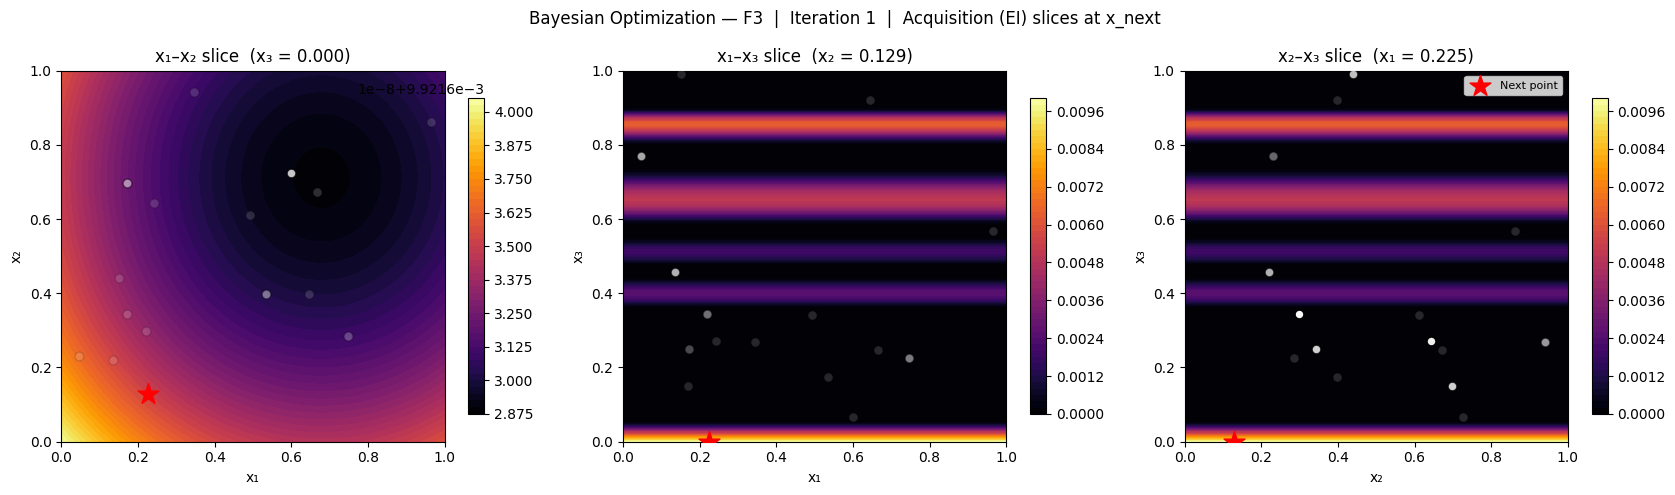

C:\Users\fakep\AppData\Local\Temp\ipykernel_12296\2963030902.py:14: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X_cand  = sampler.random(n_sobol)



  Iteration   2  |  xi = 0.04250  |  acq = EI
  Current best y (log)          : -0.034835
  ✅ Suggested x CAPSTONE       : 0.438597-0.113777-0.0
  🎯 Suggested x                : [0.438597, 0.113777, 0.0]
  📈 Acq. score                 : 0.011346


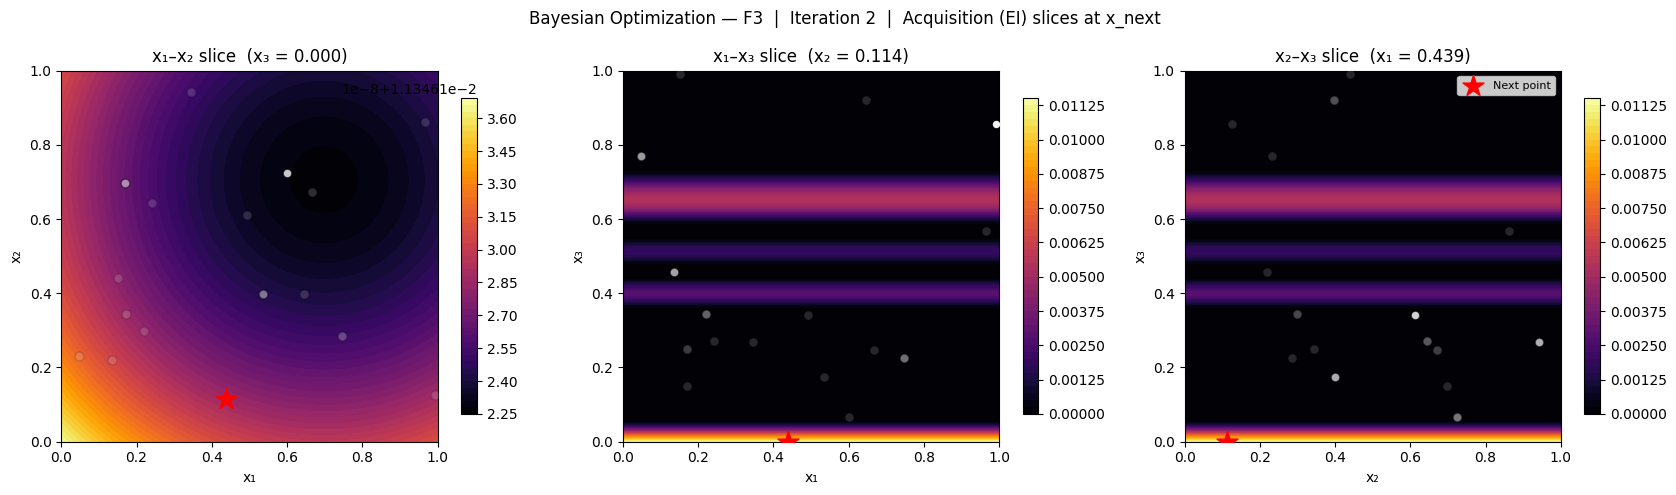

C:\Users\fakep\AppData\Local\Temp\ipykernel_12296\2963030902.py:14: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X_cand  = sampler.random(n_sobol)



  Iteration   3  |  xi = 0.03612  |  acq = EI
  Current best y (log)          : -0.034835
  ✅ Suggested x CAPSTONE       : 0.197025-0.094781-0.651338
  🎯 Suggested x                : [0.197025, 0.094781, 0.651338]
  📈 Acq. score                 : 0.006876


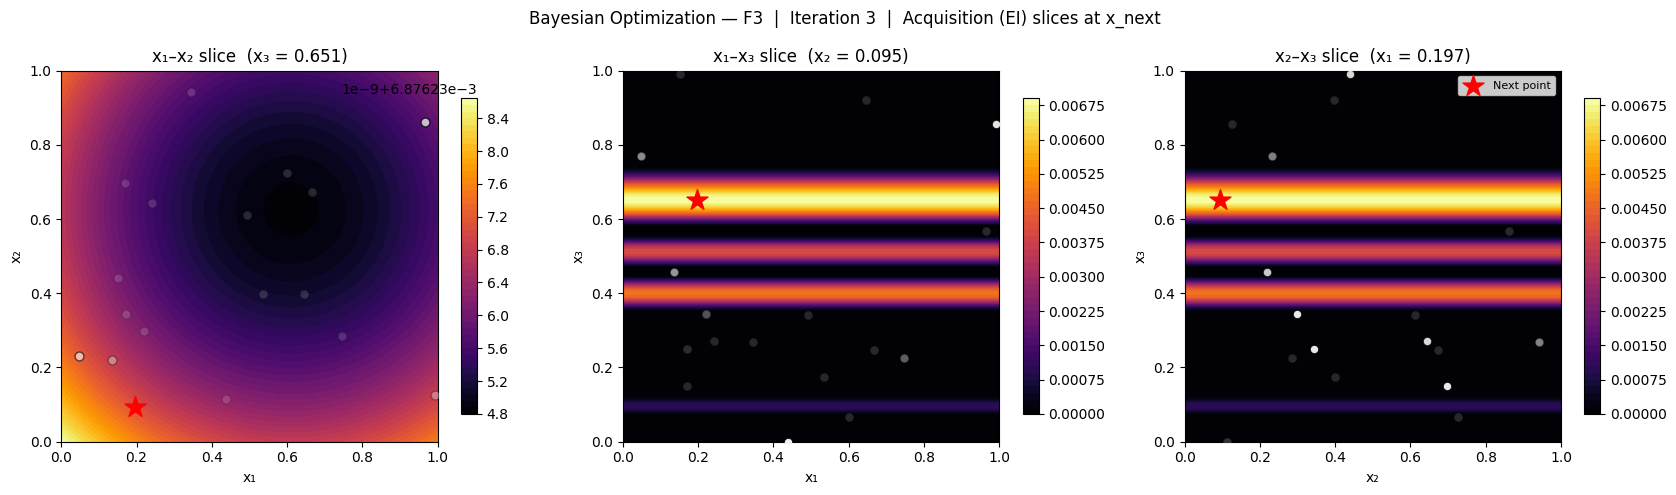

C:\Users\fakep\AppData\Local\Temp\ipykernel_12296\2963030902.py:14: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X_cand  = sampler.random(n_sobol)



  Iteration   4  |  xi = 0.03071  |  acq = EI
  Current best y (log)          : -0.034835
  ✅ Suggested x CAPSTONE       : 0.716254-0.913424-0.513716
  🎯 Suggested x                : [0.716254, 0.913424, 0.513716]
  📈 Acq. score                 : 0.006892


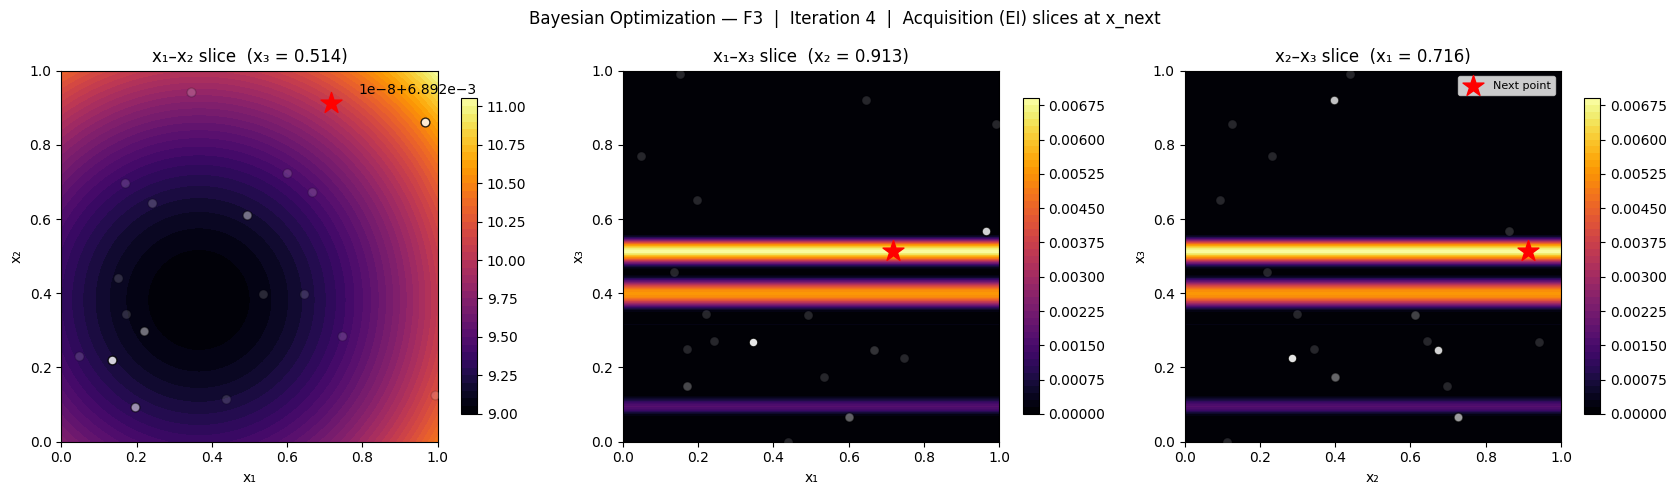

C:\Users\fakep\AppData\Local\Temp\ipykernel_12296\2963030902.py:14: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X_cand  = sampler.random(n_sobol)



  Iteration   5  |  xi = 0.02610  |  acq = EI
  Current best y (log)          : -0.034835
  ✅ Suggested x CAPSTONE       : 0.671-0.974961-0.396918
  🎯 Suggested x                : [0.671, 0.974961, 0.396918]
  📈 Acq. score                 : 0.004939


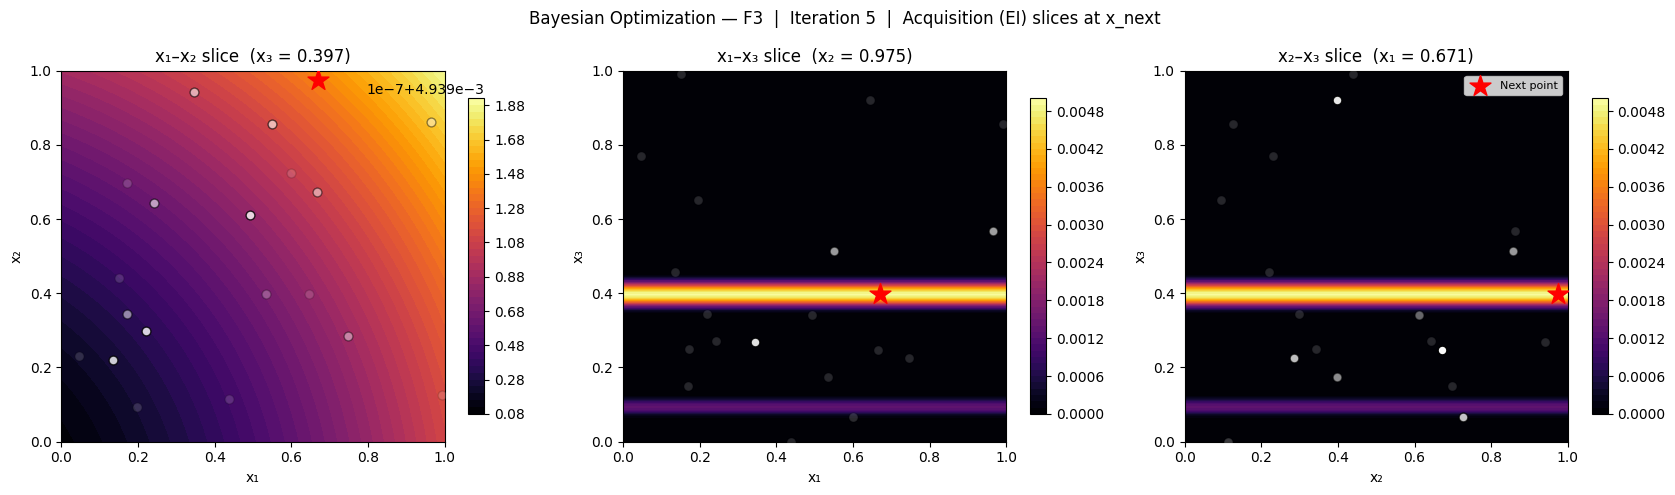

C:\Users\fakep\AppData\Local\Temp\ipykernel_12296\2963030902.py:14: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X_cand  = sampler.random(n_sobol)



  Iteration   6  |  xi = 0.02219  |  acq = EI
  Current best y (log)          : -0.034835
  ✅ Suggested x CAPSTONE       : 0.858637-0.040968-0.091608
  🎯 Suggested x                : [0.858637, 0.040968, 0.091608]
  📈 Acq. score                 : 0.001128


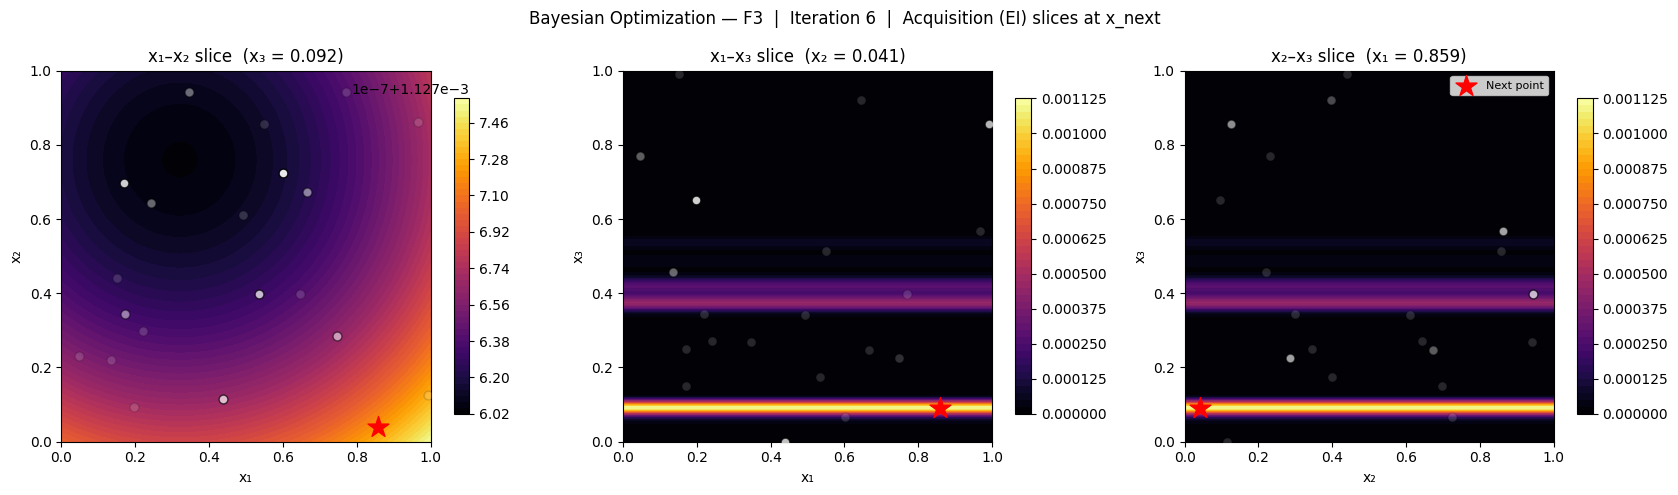

C:\Users\fakep\AppData\Local\Temp\ipykernel_12296\2963030902.py:14: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X_cand  = sampler.random(n_sobol)



  Iteration   7  |  xi = 0.01886  |  acq = EI
  Current best y (log)          : -0.034835
  ✅ Suggested x CAPSTONE       : 0.271686-0.006279-0.373862
  🎯 Suggested x                : [0.271686, 0.006279, 0.373862]
  📈 Acq. score                 : 0.000942


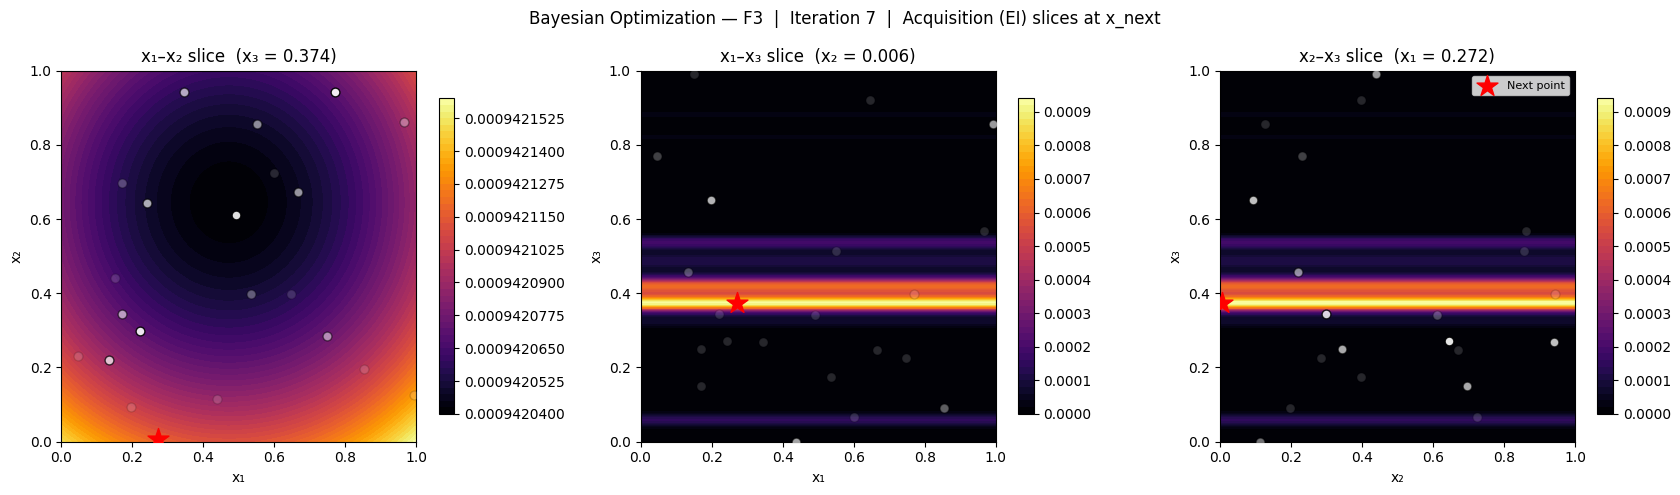

C:\Users\fakep\AppData\Local\Temp\ipykernel_12296\2963030902.py:14: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X_cand  = sampler.random(n_sobol)



  Iteration   8  |  xi = 0.01603  |  acq = EI
  Current best y (log)          : -0.034835
  ✅ Suggested x CAPSTONE       : 0.902771-1.0-0.854257
  🎯 Suggested x                : [0.902771, 1.0, 0.854257]
  📈 Acq. score                 : 0.016464


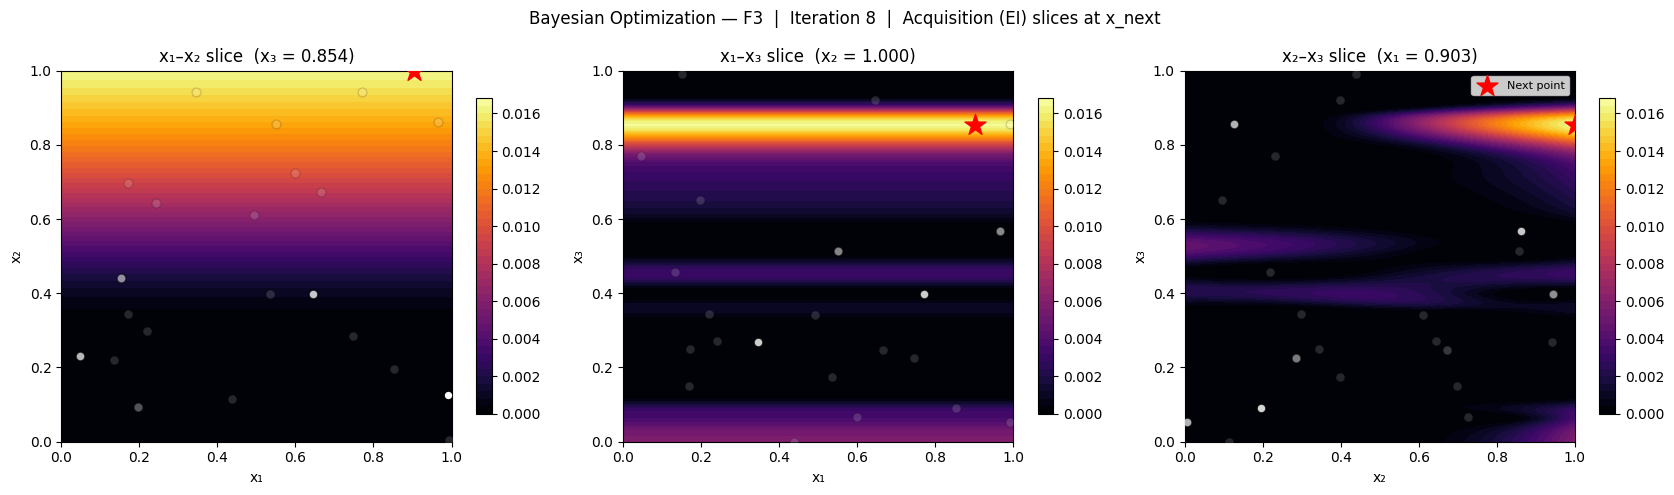

C:\Users\fakep\AppData\Local\Temp\ipykernel_12296\2963030902.py:14: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X_cand  = sampler.random(n_sobol)



  Iteration   9  |  xi = 0.01362  |  acq = EI
  Current best y (log)          : -0.034835
  ✅ Suggested x CAPSTONE       : 0.09641-1.0-0.085744
  🎯 Suggested x                : [0.09641, 1.0, 0.085744]
  📈 Acq. score                 : 0.008656


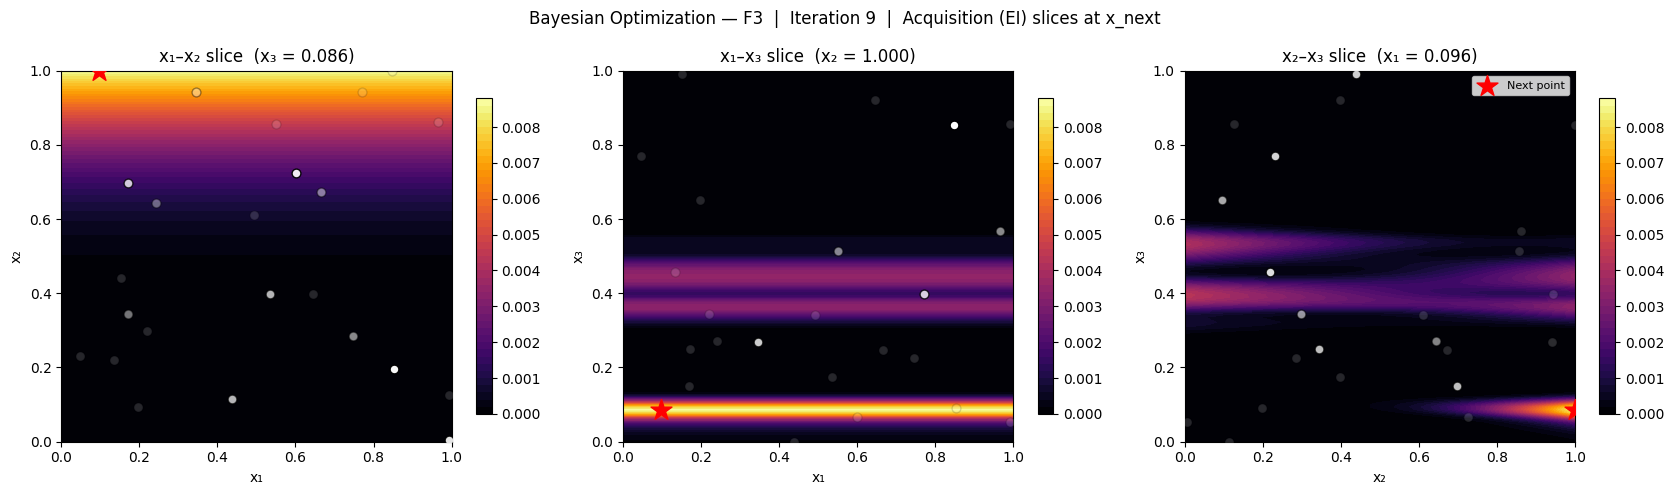

C:\Users\fakep\AppData\Local\Temp\ipykernel_12296\2963030902.py:14: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X_cand  = sampler.random(n_sobol)



  Iteration  10  |  xi = 0.01158  |  acq = EI
  Current best y (log)          : -0.034835
  ✅ Suggested x CAPSTONE       : 0.061939-0.131221-0.38074
  🎯 Suggested x                : [0.061939, 0.131221, 0.38074]
  📈 Acq. score                 : 0.005117


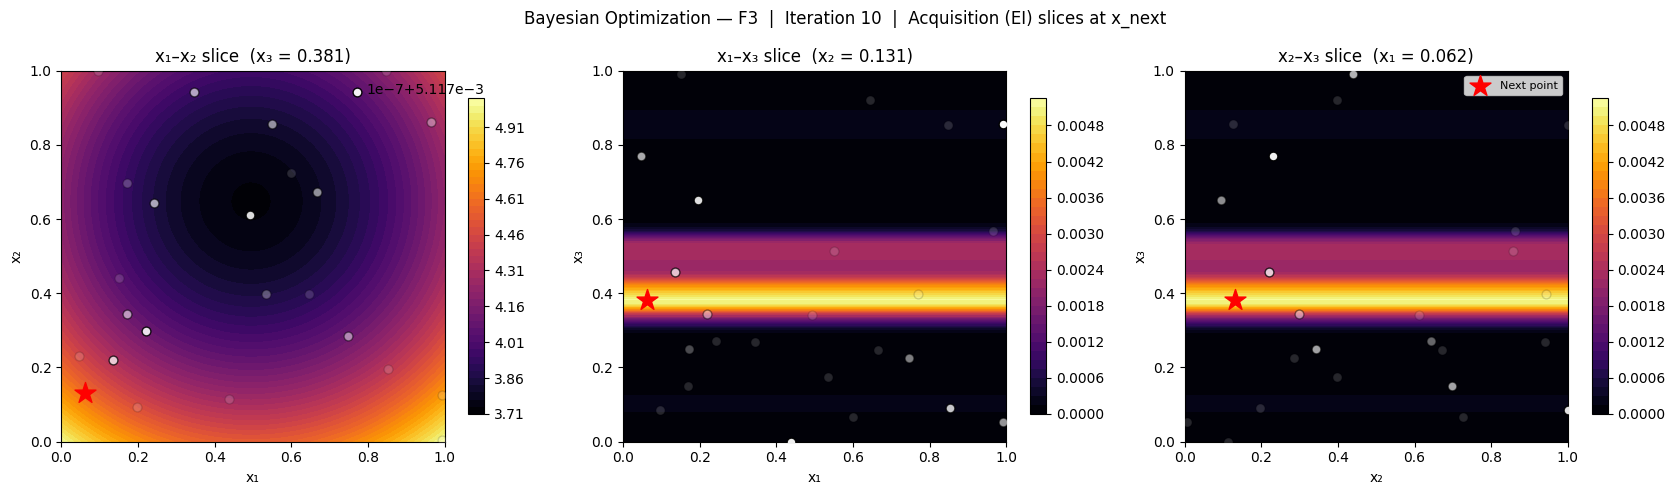

C:\Users\fakep\AppData\Local\Temp\ipykernel_12296\2963030902.py:14: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X_cand  = sampler.random(n_sobol)



  Iteration  11  |  xi = 0.00984  |  acq = EI
  Current best y (log)          : -0.034835
  ✅ Suggested x CAPSTONE       : 0.944314-1.0-0.0
  🎯 Suggested x                : [0.944314, 1.0, 0.0]
  📈 Acq. score                 : 0.007293


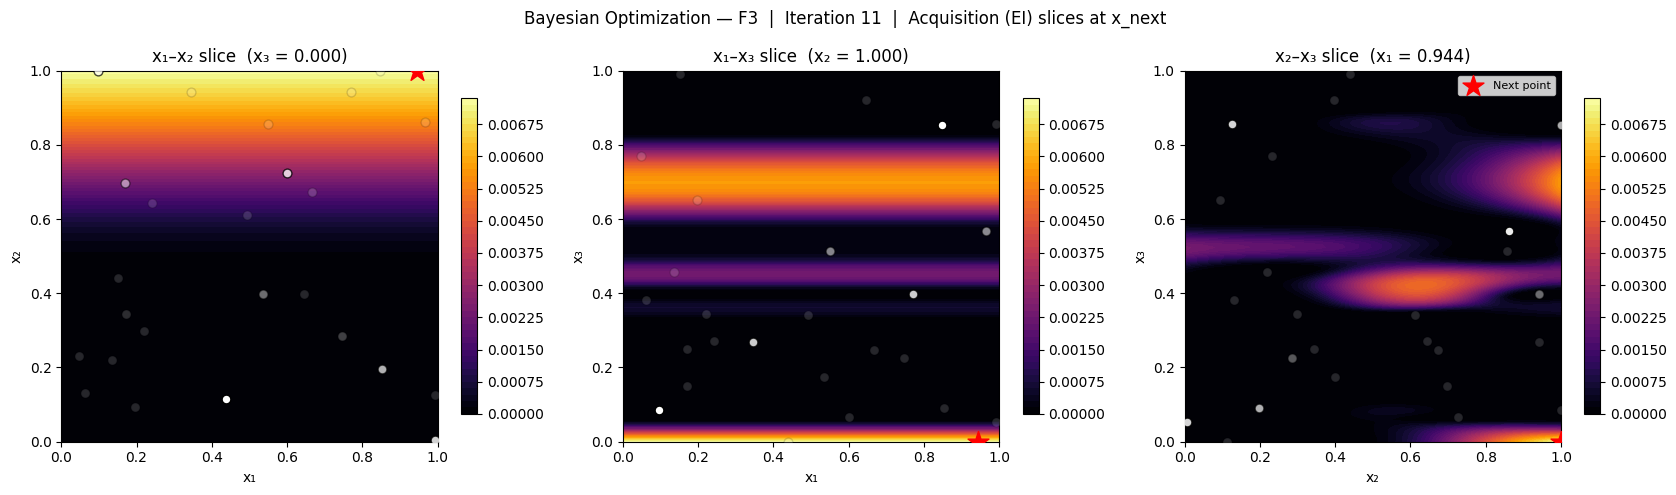

C:\Users\fakep\AppData\Local\Temp\ipykernel_12296\2963030902.py:14: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X_cand  = sampler.random(n_sobol)



  Iteration  12  |  xi = 0.00837  |  acq = EI
  Current best y (log)          : -0.034835
  ✅ Suggested x CAPSTONE       : 0.945949-0.800714-0.429606
  🎯 Suggested x                : [0.945949, 0.800714, 0.429606]
  📈 Acq. score                 : 0.003131


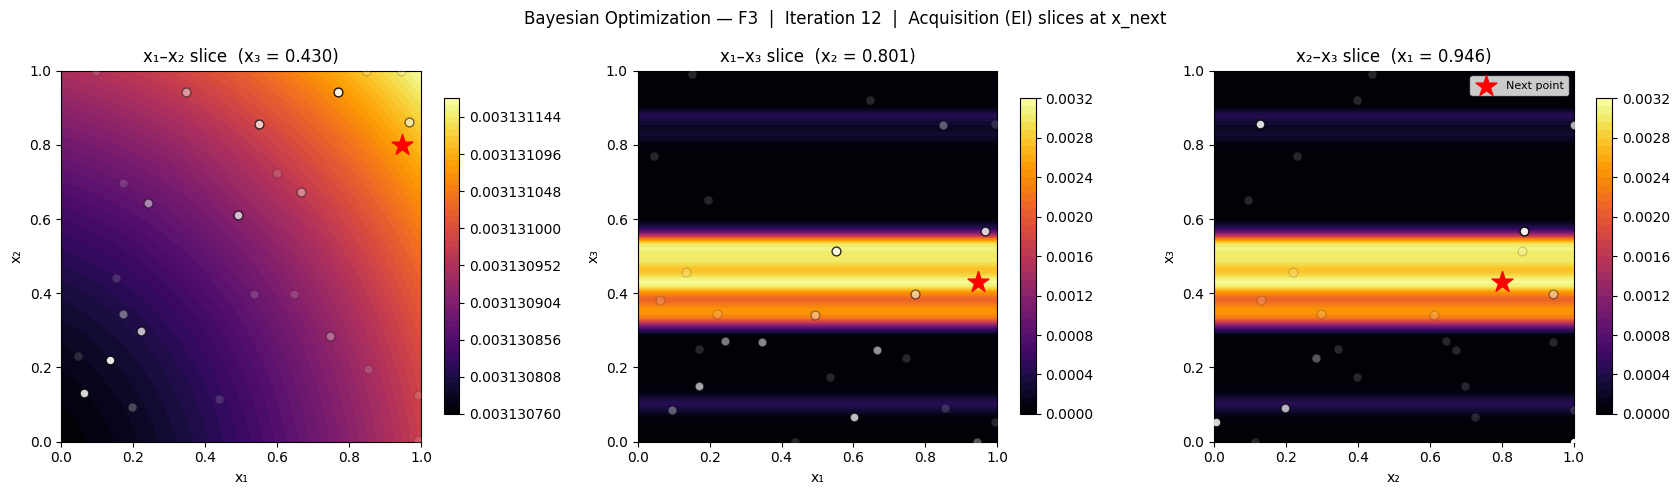

In [7]:
# ── Past Week Data ─────────────────────────────────────────────────────────────
X_new_Data = np.array([]).reshape(0, 3)
y_new_Data = np.array([])

# Week1 addition
X_new_Data = np.vstack([X_new_Data, [0.992217, 0.126864, 0.856727]])
y_new_Data = np.hstack([y_new_Data, -0.06969419994675573])

# Week2 addition
X_new_Data = np.vstack([X_new_Data, [0.438597, 0.113777, 0.000000]])
y_new_Data = np.hstack([y_new_Data, -0.14467751724572522])

# Week3 addition
X_new_Data = np.vstack([X_new_Data, [0.197025, 0.094781, 0.651338]])
y_new_Data = np.hstack([y_new_Data, -0.17500406285080186])

# Week4 addition
X_new_Data = np.vstack([X_new_Data, [0.550237, 0.855756, 0.513800]])
y_new_Data = np.hstack([y_new_Data, -0.04843256209298957])

# Week5 addition
X_new_Data = np.vstack([X_new_Data, [0.770461, 0.942718, 0.396727]])
y_new_Data = np.hstack([y_new_Data, -0.03555667625951792])

# Week6 addition
X_new_Data = np.vstack([X_new_Data, [0.853135, 0.197021, 0.091609]])
y_new_Data = np.hstack([y_new_Data, -0.06389625840261])

# Week7 addition
X_new_Data = np.vstack([X_new_Data, [0.992568, 0.005685, 0.054383]])
y_new_Data = np.hstack([y_new_Data, -0.1171657211692006])

# Week8 addition
X_new_Data = np.vstack([X_new_Data, [0.848134, 1.000000, 0.854384]])
y_new_Data = np.hstack([y_new_Data, -0.07475511331071162])

# Week9 addition
X_new_Data = np.vstack([X_new_Data, [0.096410, 1.000000, 0.085744]])
y_new_Data = np.hstack([y_new_Data, -0.07678618264967974])

# Week10 addition
X_new_Data = np.vstack([X_new_Data, [0.061939, 0.131221, 0.380739]])
y_new_Data = np.hstack([y_new_Data, -0.06456520546003719])

# Week12 addition
X_new_Data = np.vstack([X_new_Data, [0.944314, 1.000000, 0.000000]])
y_new_Data = np.hstack([y_new_Data, -0.16381347560268283])

# ── Configuration ─────────────────────────────────────────────────────────────
N_ITER   = len(y_new_Data)+1       # number of BO steps to run
ACQ      = "ei"    # "ei" or "ucb"
XI_INIT  = 0.05
XI_DECAY = 0.85
KAPPA    = 2.576   # only used if ACQ = "ucb"

# ── History (seeded with initial observations) ────────────────────────────────
X_obs        = X.copy()
y_obs        = y.copy()
history_best = [y_obs.max()]

for iteration in range(N_ITER):

    # 1. Fit GP on raw outputs (no transform needed for F3)
    gp    = build_gp(n_dim)
    gp.fit(X_obs, y_obs)
    y_max = y_obs.max()

    # 2. Compute adaptive xi for this iteration
    xi = adaptive_xi(iteration, xi_init=XI_INIT, decay=XI_DECAY)

    # 3. Define acquisition callable for the plot helper
    if ACQ == "ucb":
        acq_fn    = lambda X_c: upper_confidence_bound(X_c, gp, kappa=KAPPA)
        acq_label = "UCB"
    else:
        acq_fn    = lambda X_c: expected_improvement(X_c, gp, y_max, xi=xi)
        acq_label = "EI"

    # 4. Suggest next point
    x_next, score = suggest_next_point(
        gp, y_max, n_dim,
        xi=xi, acq=ACQ, kappa=KAPPA,
        seed=SEED + iteration
    )

    # 5. Print summary
    print("\n" + "="*62)
    print(f"  Iteration {iteration + 1:>3d}  |  xi = {xi:.5f}  |  acq = {acq_label}")
    print(f"  Current best y (log)          : {y_max:.6f}")
    print(f"  ✅ Suggested x CAPSTONE       : {np.round(x_next[0], 6)}-{np.round(x_next[1], 6)}-{np.round(x_next[2], 6)}")
    print(f"  🎯 Suggested x                : {np.round(x_next, 6).tolist()}")
    print(f"  📈 Acq. score                 : {score:.6f}")
    print("="*62)

    # 6. Visualise acquisition slices around x_next
    plot_slices_3d(gp, X_obs, x_next, acq_fn,
                   iteration=iteration + 1, acq_label=acq_label)

    # ── PAST WEEKS DATA ──────────────────────────────────────────────
    if iteration < len(y_new_Data):
        y_new  = y_new_Data[iteration]
        X_obs  = np.vstack([X_obs, X_new_Data[iteration]])
        y_obs  = np.append(y_obs, y_new)
        history_best.append(y_obs.max())
    # ─────────────────────────────────────────────────────────────────────────

## 8. SVM classifier on observed data

In [8]:
# Threshold: top 25% of log-transformed observations = "high"
threshold = np.percentile(y_obs, 75)
labels = (y_obs >= threshold).astype(int)  # 1 = high, 0 = low

print(f"Threshold (75th pct, log-space): {threshold:.4f}")
print(f"High-performing points : {labels.sum()} / {len(labels)}")

# Scale inputs (SVM is sensitive to scale)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_obs)

# Soft-margin SVM with RBF kernel (handles non-linear boundaries)
# C controls margin softness: lower C = wider margin, more generalisation
# gamma='scale' = 1/(n_features * X.var()), a robust default
svm = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True)
svm.fit(X_scaled, labels)

print(f"\nSVM kernel  : {svm.kernel}")
print(f"Support vectors : {svm.n_support_} (class 0 / class 1)")

Threshold (75th pct, log-space): -0.0585
High-performing points : 7 / 26

SVM kernel  : rbf
Support vectors : [10  7] (class 0 / class 1)


## 9. Visualise the SVM decision boundary alongside GP

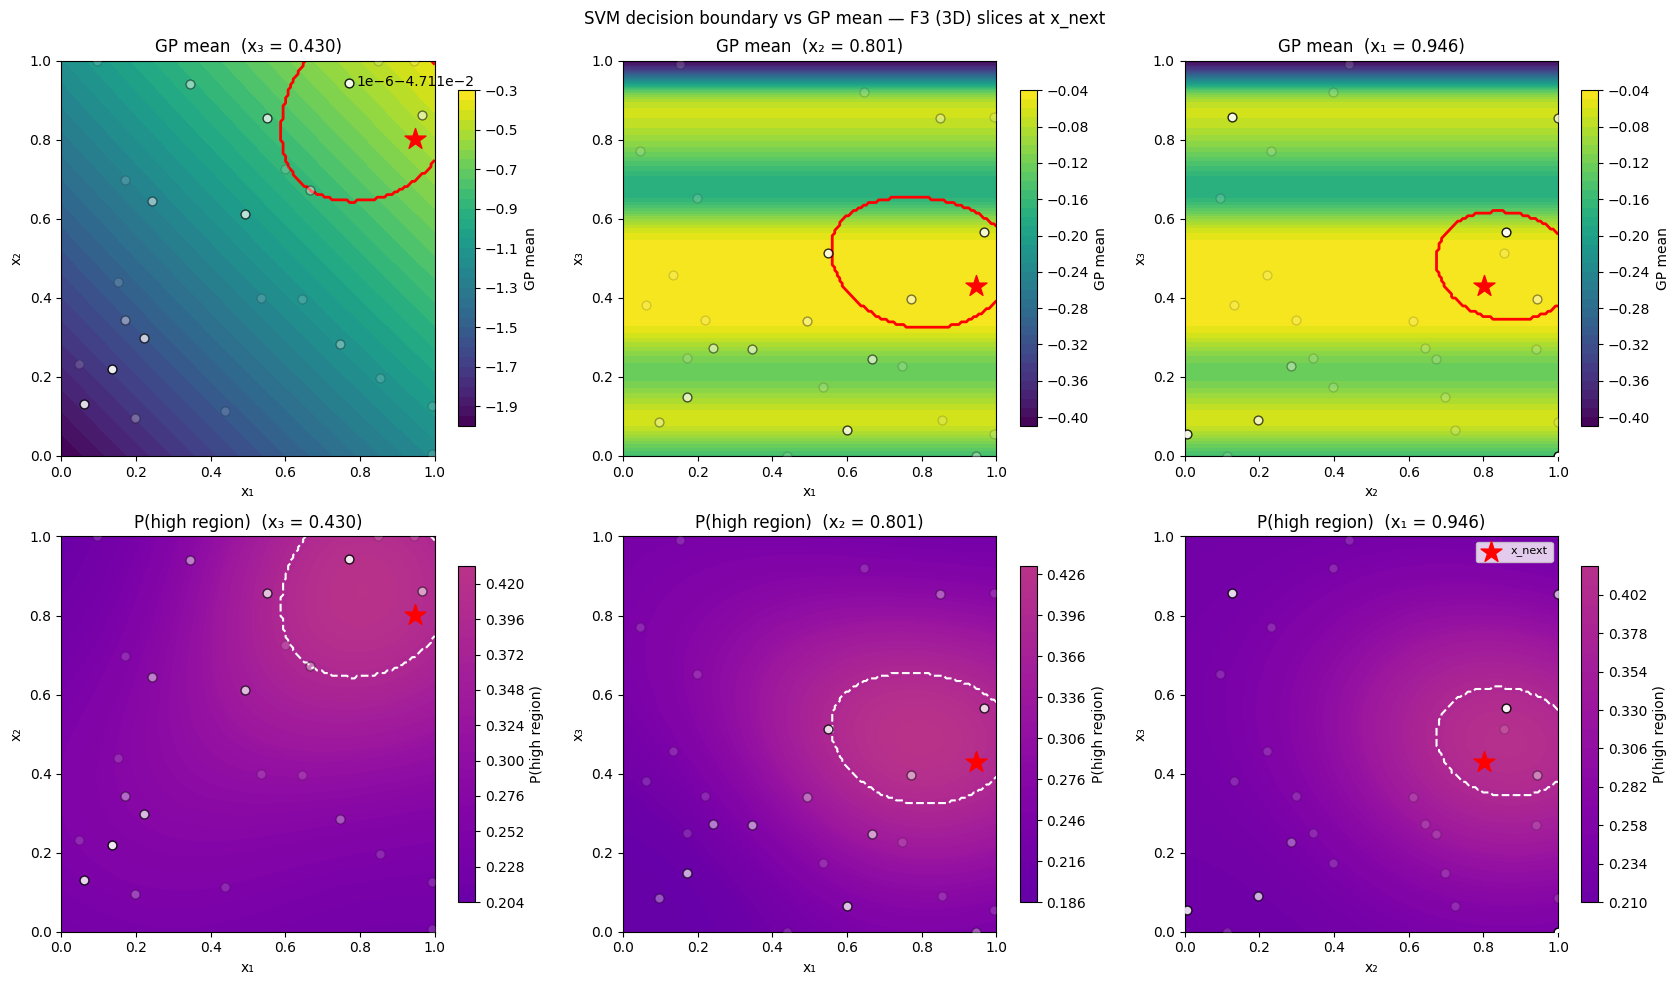

In [9]:
# ── Plot: SVM probability slices (3D → 2D projections) ───────────────────────
resolution = 150
grid_1d = np.linspace(0, 1, resolution)
G1, G2  = np.meshgrid(grid_1d, grid_1d)
flat1, flat2 = G1.ravel(), G2.ravel()

# Fix each dimension in turn at x_next's value, sweep the other two
slices = [
    (0, 1, 2, x_next[2], "x₁", "x₂", f"x₃ = {x_next[2]:.3f}"),
    (0, 2, 1, x_next[1], "x₁", "x₃", f"x₂ = {x_next[1]:.3f}"),
    (1, 2, 0, x_next[0], "x₂", "x₃", f"x₁ = {x_next[0]:.3f}"),
]

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle("SVM decision boundary vs GP mean — F3 (3D) slices at x_next", fontsize=12)

for col, (d0, d1, d_fix, v_fix, xlabel, ylabel, fix_label) in enumerate(slices):
    X_grid = np.zeros((resolution * resolution, 3))
    X_grid[:, d0]    = flat1
    X_grid[:, d1]    = flat2
    X_grid[:, d_fix] = v_fix

    # GP mean
    mu_slice, _ = gp.predict(X_grid, return_std=True)
    mu_slice    = mu_slice.reshape(resolution, resolution)

    # SVM probability
    X_grid_scaled = scaler.transform(X_grid)
    svm_prob_slice = svm.predict_proba(X_grid_scaled)[:, 1].reshape(resolution, resolution)
    svm_pred_slice = svm.predict(X_grid_scaled).reshape(resolution, resolution)

    # Top row: GP mean + SVM boundary
    ax = axes[0, col]
    im = ax.contourf(G1, G2, mu_slice, levels=40, cmap="viridis")
    fig.colorbar(im, ax=ax, shrink=0.85, label="GP mean")
    ax.contour(G1, G2, svm_pred_slice, levels=[0.5], colors="red", linewidths=2)
    dist   = np.abs(X_obs[:, d_fix] - v_fix)
    alphas = np.clip(1.0 - dist / 0.3, 0.15, 1.0)
    for xi_obs, yi_obs, a in zip(X_obs[:, d0], X_obs[:, d1], alphas):
        ax.scatter(xi_obs, yi_obs, c="white", edgecolors="black", s=40,
                   alpha=float(a), zorder=5)
    ax.scatter(x_next[d0], x_next[d1], c="red", marker="*", s=250, zorder=6)
    ax.set_title(f"GP mean  ({fix_label})")
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)

    # Bottom row: SVM P(high)
    ax = axes[1, col]
    im2 = ax.contourf(G1, G2, svm_prob_slice, levels=40, cmap="plasma", vmin=0, vmax=1)
    fig.colorbar(im2, ax=ax, shrink=0.85, label="P(high region)")
    ax.contour(G1, G2, svm_pred_slice, levels=[0.5], colors="white",
               linewidths=1.5, linestyles="--")
    for xi_obs, yi_obs, a in zip(X_obs[:, d0], X_obs[:, d1], alphas):
        ax.scatter(xi_obs, yi_obs, c="white", edgecolors="black", s=40,
                   alpha=float(a), zorder=5)
    ax.scatter(x_next[d0], x_next[d1], c="red", marker="*", s=250, zorder=6,
               label="x_next")
    ax.set_title(f"P(high region)  ({fix_label})")
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)

axes[1, 2].legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.savefig("svm_boundary_f3.png", dpi=150)
plt.show()

## 10. SVM-constrained next point suggestion

In [10]:
# ── Constrained BO: suggest next point inside SVM "high" region ──────────────
from scipy.stats import qmc

# Generate a large Sobol candidate set
sampler = qmc.Sobol(d=n_dim, scramble=True, seed=SEED + 99)
X_cand = sampler.random(20_000)

# Keep only candidates the SVM classifies as "high"
X_cand_scaled = scaler.transform(X_cand)
svm_labels    = svm.predict(X_cand_scaled)
svm_probs     = svm.predict_proba(X_cand_scaled)[:, 1]

# Filter: inside SVM high region AND probability > 0.5
mask = (svm_labels == 1) & (svm_probs > 0.5)
X_constrained = X_cand[mask]

print(f"Candidates in high region : {mask.sum()} / {len(X_cand)} "
      f"({100*mask.mean():.1f}% of space)")

if len(X_constrained) < 10:
    # Fallback: boundary too restrictive, use full candidate set
    print("⚠️  Fewer than 10 constrained candidates — falling back to full set.")
    X_constrained = X_cand

# Score with EI inside the constrained region only
xi_constrained = adaptive_xi(N_ITER, xi_init=XI_INIT, decay=XI_DECAY)
ei_scores = expected_improvement(X_constrained, gp, y_obs.max(), xi=xi_constrained)

# Local optimisation from top-8 starts within the constrained region
starts = X_constrained[np.argsort(ei_scores)[-8:]]
bounds = [(0, 1)] * n_dim
obj    = lambda x: -expected_improvement(x, gp, y_obs.max(), xi=xi_constrained).item()

best_x_svm, best_score_svm = None, -np.inf
for x0 in starts:
    res = minimize(obj, x0=x0, bounds=bounds, method="L-BFGS-B")
    if -res.fun > best_score_svm:
        best_score_svm = -res.fun
        best_x_svm     = res.x

print(f"\n{'='*55}")
print(f"  SVM-constrained suggestion")
print(f"  Suggested x : {np.round(best_x_svm, 6).tolist()}")
print(f"  EI score    : {best_score_svm:.6f}")
print(f"  xi used     : {xi_constrained:.5f}")
print(f"  ✅ CAPSTONE format : {np.round(best_x_svm[0],6)}-{np.round(best_x_svm[1],6)}-{np.round(best_x_svm[2],6)}")
print(f"{'='*55}")

Candidates in high region : 0 / 20000 (0.0% of space)
⚠️  Fewer than 10 constrained candidates — falling back to full set.

  SVM-constrained suggestion
  Suggested x : [0.866211, 0.879935, 0.429569]
  EI score    : 0.003407
  xi used     : 0.00711
  ✅ CAPSTONE format : 0.866211-0.879935-0.429569


C:\Users\fakep\AppData\Local\Temp\ipykernel_12296\3510325856.py:6: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X_cand = sampler.random(20_000)


## 11. Neural Network Surrogate (MC Dropout)

We use a **PyTorch MLP with Monte Carlo Dropout** as a third surrogate. Unlike the GP (which has a closed-form posterior) or the SVM (which only classifies regions), the NN learns a direct regression mapping from input to output.

**Why MC Dropout for uncertainty?**
Dropout randomly zeroes neurons during training to prevent co-adaptation. At inference time, keeping dropout *active* and running multiple forward passes produces a distribution of predictions — the mean is the surrogate's prediction and the standard deviation is its uncertainty estimate (Gal & Ghahramani, 2016).

**Architecture:**
- 2 hidden layers of 32 units with ReLU activations
- Dropout rate = 0.1 between each layer
- Trained with Adam + L2 weight decay on normalised targets
- Uncertainty = std across 200 stochastic forward passes

> **F3 note:** This is a 3D function. The NN receives 3-dimensional inputs and trains on raw y values (normalised to N(0,1)). The visualisation uses the same 2D slice approach as the GP plots.

In [11]:
class MCDropoutNN(nn.Module):
    """MLP with dropout kept active at inference for uncertainty quantification."""

    def __init__(self, n_in, hidden=32, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_in, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

    def mc_predict(self, x_tensor, n_samples=200):
        """n_samples stochastic forward passes → (mean, std) as numpy arrays."""
        self.train()   # keep dropout active during inference
        with torch.no_grad():
            preds = torch.stack([self(x_tensor) for _ in range(n_samples)])
        return preds.mean(0).numpy(), preds.std(0).numpy()


# ── Normalise inputs and targets ──────────────────────────────────────────────
scaler_nn = StandardScaler()
X_nn      = scaler_nn.fit_transform(X_obs)

y_nn_mean = y_obs.mean()
y_nn_std  = max(y_obs.std(), 1e-8)
y_nn      = (y_obs - y_nn_mean) / y_nn_std   # N(0,1) targets

X_t = torch.tensor(X_nn, dtype=torch.float32)
y_t = torch.tensor(y_nn, dtype=torch.float32)

# ── Train ─────────────────────────────────────────────────────────────────────
torch.manual_seed(SEED)
nn_model  = MCDropoutNN(n_dim, hidden=32, dropout=0.1)
optimizer = optim.Adam(nn_model.parameters(), lr=1e-3, weight_decay=1e-4)
loss_fn   = nn.MSELoss()

nn_model.train()
for epoch in range(3000):
    optimizer.zero_grad()
    loss = loss_fn(nn_model(X_t), y_t)
    loss.backward()
    optimizer.step()

print(f"NN trained — final MSE loss: {loss.item():.6f}")

# ── Sanity check on training data ─────────────────────────────────────────────
mu_chk, sig_chk = nn_model.mc_predict(X_t, n_samples=200)
mu_chk_raw = mu_chk * y_nn_std + y_nn_mean
print(f"NN mean pred range (raw) : [{mu_chk_raw.min():.4f}, {mu_chk_raw.max():.4f}]")
print(f"NN uncertainty std range : [{sig_chk.min():.4f},  {sig_chk.max():.4f}]")

NN trained — final MSE loss: 0.020507
NN mean pred range (raw) : [-0.4072, -0.0412]
NN uncertainty std range : [0.0604,  0.5870]


## 12. NN-constrained next point suggestion

We define EI using the MC-Dropout NN's predicted mean (μ) and standard deviation (σ), then run the same Sobol + L-BFGS-B optimisation used for the GP — here with 32,768 Sobol candidates (power-of-2, appropriate for 3D).

In [12]:
def expected_improvement_nn(X_cand, nn_model, scaler_nn, y_nn_mean, y_nn_std,
                             y_max, xi=0.01, n_mc=200):
    """EI using MC-Dropout NN surrogate — operates on raw (untransformed) y values."""
    X_cand   = np.atleast_2d(X_cand)
    X_scaled = scaler_nn.transform(X_cand)
    X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
    mu_norm, sigma_norm = nn_model.mc_predict(X_tensor, n_samples=n_mc)
    # Un-normalise back to raw y-space
    mu    = mu_norm  * y_nn_std + y_nn_mean
    sigma = np.maximum(sigma_norm * y_nn_std, 1e-8)
    imp   = mu - y_max - xi
    Z     = imp / sigma
    ei    = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
    ei[sigma <= 1e-8] = 0.0
    return ei


xi_nn = adaptive_xi(N_ITER, xi_init=XI_INIT, decay=XI_DECAY)

# Sobol candidates — 32k is a good power-of-2 size for 3D
sampler_nn   = qmc.Sobol(d=n_dim, scramble=True, seed=SEED + 199)
X_cand_nn    = sampler_nn.random(32_768)

ei_nn_scores = expected_improvement_nn(
    X_cand_nn, nn_model, scaler_nn, y_nn_mean, y_nn_std, y_obs.max(), xi=xi_nn
)

# Local optimisation from top-10 Sobol starts (matches GP's n_best for 3D)
starts_nn = X_cand_nn[np.argsort(ei_nn_scores)[-10:]]
obj_nn    = lambda x: -expected_improvement_nn(
    x, nn_model, scaler_nn, y_nn_mean, y_nn_std, y_obs.max(), xi=xi_nn
).item()

best_x_nn, best_score_nn = None, -np.inf
for x0 in starts_nn:
    res = minimize(obj_nn, x0=x0, bounds=[(0, 1)] * n_dim, method="L-BFGS-B")
    if -res.fun > best_score_nn:
        best_score_nn = -res.fun
        best_x_nn     = res.x

print(f"\n{'='*60}")
print(f"  NN (MC Dropout) suggestion")
print(f"  Suggested x : {np.round(best_x_nn, 6).tolist()}")
print(f"  EI score    : {best_score_nn:.6f}")
print(f"  xi used     : {xi_nn:.5f}")
print(f"  ✅ CAPSTONE format : {np.round(best_x_nn[0],6)}-{np.round(best_x_nn[1],6)}-{np.round(best_x_nn[2],6)}")
print(f"{'='*60}")


  NN (MC Dropout) suggestion
  Suggested x : [0.629274, 0.801393, 0.002453]
  EI score    : 0.000562
  xi used     : 0.00711
  ✅ CAPSTONE format : 0.629274-0.801393-0.002453


## 13. Visualise the NN surrogate surface (3D slices)

Three panels show the **NN EI surface** as 2D slices — one per coordinate plane, each fixed at `best_x_nn`'s value in that dimension. This mirrors the GP acquisition slice plots in Section 6.

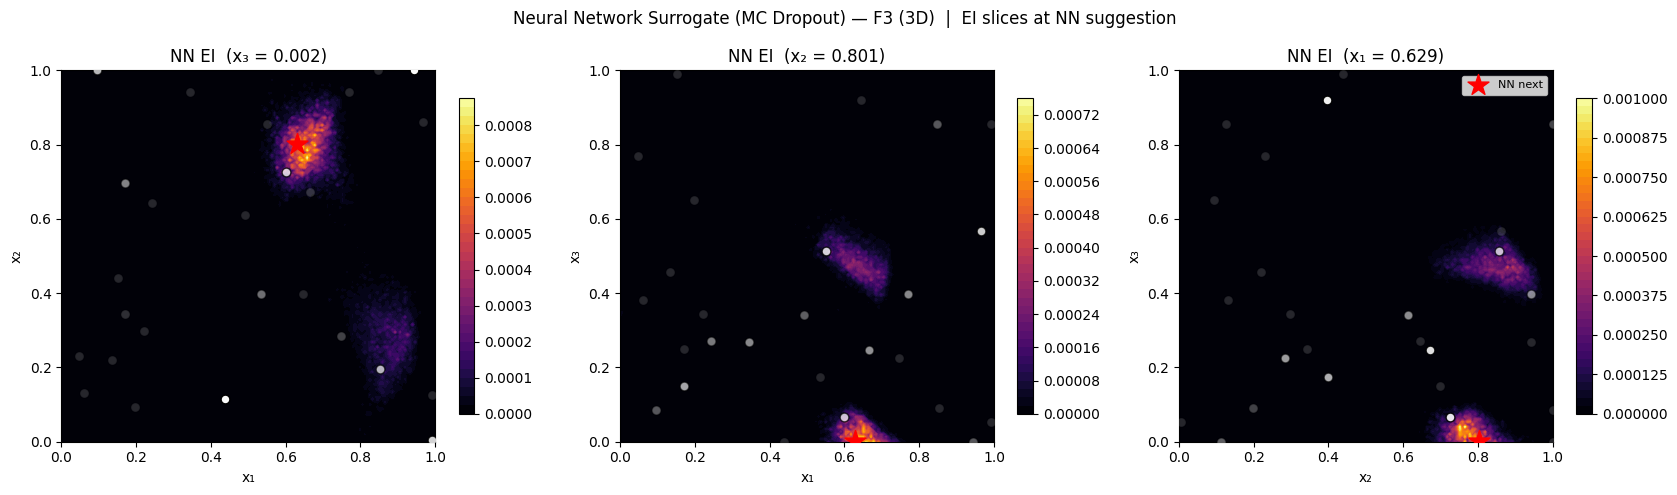

In [13]:
resolution = 150
grid_1d    = np.linspace(0, 1, resolution)
G1, G2     = np.meshgrid(grid_1d, grid_1d)
flat1, flat2 = G1.ravel(), G2.ravel()

slices = [
    (0, 1, 2, best_x_nn[2], "x₁", "x₂", f"x₃ = {best_x_nn[2]:.3f}"),
    (0, 2, 1, best_x_nn[1], "x₁", "x₃", f"x₂ = {best_x_nn[1]:.3f}"),
    (1, 2, 0, best_x_nn[0], "x₂", "x₃", f"x₁ = {best_x_nn[0]:.3f}"),
]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle(
    "Neural Network Surrogate (MC Dropout) — F3 (3D)  |  EI slices at NN suggestion",
    fontsize=12
)

for ax, (d0, d1, d_fix, v_fix, xlabel, ylabel, fix_label) in zip(axes, slices):
    X_grid = np.zeros((resolution * resolution, 3))
    X_grid[:, d0]    = flat1
    X_grid[:, d1]    = flat2
    X_grid[:, d_fix] = v_fix

    ei_vals = expected_improvement_nn(
        X_grid, nn_model, scaler_nn, y_nn_mean, y_nn_std, y_obs.max(), xi=xi_nn, n_mc=200
    ).reshape(resolution, resolution)

    im = ax.contourf(G1, G2, ei_vals, levels=40, cmap="inferno")
    fig.colorbar(im, ax=ax, shrink=0.85)

    dist   = np.abs(X_obs[:, d_fix] - v_fix)
    alphas = np.clip(1.0 - dist / 0.3, 0.15, 1.0)
    for xi_o, yi_o, a in zip(X_obs[:, d0], X_obs[:, d1], alphas):
        ax.scatter(xi_o, yi_o, c="white", edgecolors="black",
                   s=40, alpha=float(a), zorder=5)

    ax.scatter(best_x_nn[d0], best_x_nn[d1], c="red", marker="*",
               s=250, zorder=6, label="NN next")
    ax.set_title(f"NN EI  ({fix_label})")
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)

axes[2].legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.savefig("nn_surrogate_f3.png", dpi=150)
plt.show()

## 14. Compare all three models: GP vs SVM vs NN

We compare the **EI score** and **suggested next point** from each surrogate:

| Model | Surrogate type | Uncertainty source |
|---|---|---|
| **GP** | Matérn 5/2 kernel | Bayesian posterior (exact) |
| **SVM** | RBF classifier | P(high region) — filters candidates |
| **NN** | MC-Dropout MLP | 200 stochastic forward passes |

A bar chart visualises the EI values directly, and pairwise distances quantify agreement between the three suggestions.

Model                                                 Suggested x           EI
--------------------------------------------------------------------------------
GP (unconstrained)                 [0.945949, 0.800714, 0.429606]     0.003131
SVM-constrained                    [0.866211, 0.879935, 0.429569]     0.003407
NN (MC Dropout)                    [0.629274, 0.801393, 0.002453]     0.000562

GP  ↔ SVM distance : 0.1124
GP  ↔ NN  distance : 0.5317
SVM ↔ NN  distance : 0.4947

❗ Strong disagreement — models see different promising regions; trust the GP.


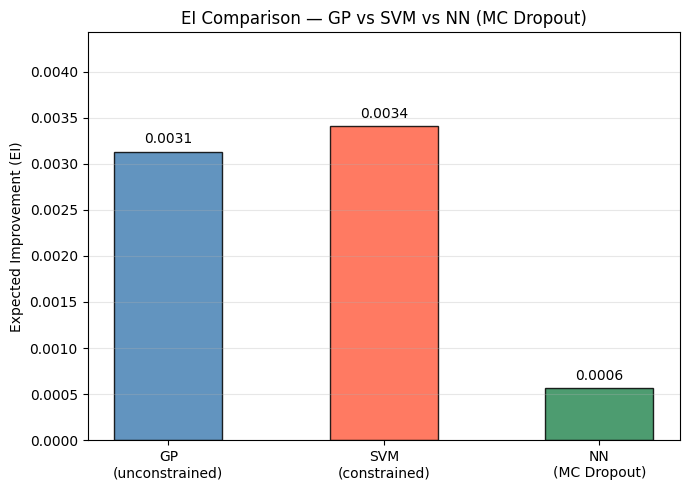

In [14]:
# ── Summary table ─────────────────────────────────────────────────────────────
print(f"{'Model':<24} {'Suggested x':>40}   {'EI':>10}")
print("-" * 80)
print(f"{'GP (unconstrained)':<24} {str(np.round(x_next, 6).tolist()):>40}   {score:>10.6f}")
print(f"{'SVM-constrained':<24} {str(np.round(best_x_svm, 6).tolist()):>40}   {best_score_svm:>10.6f}")
print(f"{'NN (MC Dropout)':<24} {str(np.round(best_x_nn, 6).tolist()):>40}   {best_score_nn:>10.6f}")

# ── Pairwise distances ────────────────────────────────────────────────────────
dist_gp_svm = np.linalg.norm(x_next - best_x_svm)
dist_gp_nn  = np.linalg.norm(x_next - best_x_nn)
dist_svm_nn = np.linalg.norm(best_x_svm - best_x_nn)

print(f"\nGP  ↔ SVM distance : {dist_gp_svm:.4f}")
print(f"GP  ↔ NN  distance : {dist_gp_nn:.4f}")
print(f"SVM ↔ NN  distance : {dist_svm_nn:.4f}")

# ── Consensus check ───────────────────────────────────────────────────────────
suggestions = [x_next, best_x_svm, best_x_nn]
centroid    = np.mean(suggestions, axis=0)
max_dev     = max(np.linalg.norm(s - centroid) for s in suggestions)

if max_dev < 0.05:
    print("\n✅ All three models agree — very high confidence in this region.")
elif max_dev < 0.15:
    print("\n⚠️  Mild disagreement — GP posterior is most principled; prefer GP suggestion.")
else:
    print("\n❗ Strong disagreement — models see different promising regions; trust the GP.")

# ── Bar chart: EI scores across the three surrogates ─────────────────────────
labels_bar    = ["GP\n(unconstrained)", "SVM\n(constrained)", "NN\n(MC Dropout)"]
ei_scores_bar = [score, best_score_svm, best_score_nn]
colors_bar    = ["steelblue", "tomato", "seagreen"]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(labels_bar, ei_scores_bar, color=colors_bar,
              edgecolor="black", alpha=0.85, width=0.5)
ax.bar_label(bars, fmt="%.4f", padding=4, fontsize=10)
ax.set_ylabel("Expected Improvement (EI)")
ax.set_title("EI Comparison — GP vs SVM vs NN (MC Dropout)")
ax.set_ylim(0, max(ei_scores_bar) * 1.3)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("ei_comparison_three_models_f3.png", dpi=150)
plt.show()

## 15. Hyperparameter Sensitivity — ξ (xi) Exploration (Module 18)

Module 18 identifies **ξ (xi)** as the key hyperparameter of the EI acquisition function controlling the exploration–exploitation trade-off. Rather than relying solely on the adaptive decay schedule, this section applies a **coarse grid search** over ξ — the simplest tuning strategy from Mini-lesson 18.5.

By scanning ξ ∈ {0.001 … 0.5} with the GP already fitted on all 3D observations, we can:
- Confirm the adaptive ξ is in a sensible range for the current dataset
- See how sensitive the suggested query is to this hyperparameter
- Decide whether to override the schedule if the function appears nearly converged (small ξ) or still widely uncertain (large ξ)

In [15]:
# ── ξ (xi) grid search — treating xi as a hyperparameter to tune ──────────────────
print('GP suggestion sensitivity to xi (exploration-exploitation hyperparameter):')
print(f"{'xi':>8}  {'EI score':>12}  Suggested x (CAPSTONE format)")
print('-' * 85)

xi_grid    = [0.001, 0.01, 0.05, 0.1, 0.5]
xi_current = adaptive_xi(N_ITER, xi_init=XI_INIT, decay=XI_DECAY)

for xi_test in xi_grid:
    sampler_s  = qmc.Sobol(d=n_dim, scramble=True, seed=SEED + 888)
    X_c_s      = sampler_s.random(8_192)          # 2^13 quick scan
    scores_s   = expected_improvement(X_c_s, gp, y_obs.max(), xi=xi_test)
    starts_s   = X_c_s[np.argsort(scores_s)[-5:]]
    obj_s      = lambda x, xi=xi_test: -expected_improvement(x, gp, y_obs.max(), xi=xi).item()
    bx_s, bs_s = None, -np.inf
    for x0 in starts_s:
        r = minimize(obj_s, x0=x0, bounds=[(0, 1)] * n_dim, method='L-BFGS-B')
        if -r.fun > bs_s: bs_s = -r.fun; bx_s = r.x
    capstone_s = '-'.join(f'{v:.6f}' for v in bx_s)
    marker     = '  <- adaptive (current)' if abs(xi_test - xi_current) < 0.02 else ''
    print(f'  {xi_test:>6.3f}  {bs_s:>12.6f}  {capstone_s}{marker}')

print(f'\nAdaptive xi at iteration {N_ITER}: {xi_current:.5f}  '
      f'(xi_init={XI_INIT}, decay={XI_DECAY}^{N_ITER})')

GP suggestion sensitivity to xi (exploration-exploitation hyperparameter):
      xi      EI score  Suggested x (CAPSTONE format)
-------------------------------------------------------------------------------------
   0.001      0.005025  0.702511-0.961055-0.429368  <- adaptive (current)
   0.010      0.002798  0.702510-0.961055-0.429651  <- adaptive (current)
   0.050      0.000070  0.902297-0.798989-0.430268
   0.100      0.000000  0.801649-0.210419-0.430439
   0.500      0.000000  0.196974-0.967925-0.713581

Adaptive xi at iteration 12: 0.00711  (xi_init=0.05, decay=0.85^12)


## 16. GP Kernel Diagnostics (Module 18)

The GP kernel hyperparameters are fitted by maximising the log-marginal-likelihood. Inspecting them connects to Module 18's insight that **length scales act as feature importance scores**:

- **Small length scale** → function changes quickly along that axis → high sensitivity → important dimension
- **Large length scale** → function is nearly flat along that axis → low sensitivity → potentially irrelevant

This mirrors Module 18's note that random search works well when only a few hyperparameters heavily influence performance — the same may be true of our 3D function's input dimensions. A large length-scale disparity is a signal to focus future queries on the most sensitive dimensions.

Fitted GP kernel hyperparameters (F3, 3D):
  Amplitude  s2   : 3.4439
  Noise level     : 6.96e-02

Per-dimension length scales:
  x1: 1000.0000  XXXXXXXXXXXXXXXXXXXXXXXXXXX
  x2: 1000.0000  XXXXXXXXXXXXXXXXXXXXXXXXXXX
  x3:    0.1216  XXXXXXX

Most  sensitive dim : x3 (ls=0.1216)
Least sensitive dim : x1 (ls=1000.0000)

[!] Length scale ratio 8223x -- function may be effectively lower-dimensional. Focus future queries around x3.


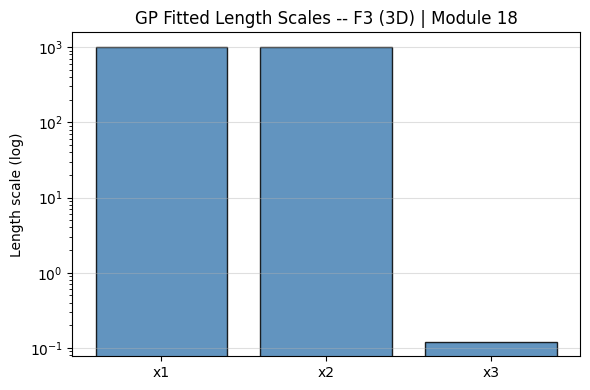

In [16]:
# ── GP fitted kernel hyperparameters ─────────────────────────────────────────────
fitted_ls = gp.kernel_.k1.k2.length_scale
noise_lv  = gp.kernel_.k2.noise_level
amplitude = gp.kernel_.k1.k1.constant_value
ls_arr    = np.array(fitted_ls)
dim_lbls  = [f'x{i+1}' for i in range(n_dim)]

print(f'Fitted GP kernel hyperparameters (F3, {n_dim}D):')
print(f'  Amplitude  s2   : {amplitude:.4f}')
print(f'  Noise level     : {noise_lv:.2e}')
print('\nPer-dimension length scales:')
for lbl, ls in zip(dim_lbls, ls_arr):
    bar = 'X' * max(1, min(int(np.log10(ls + 1e-8) * 5 + 12), 35))
    print(f'  {lbl}: {ls:9.4f}  {bar}')

if n_dim >= 3:
    idx_min, idx_max = ls_arr.argmin(), ls_arr.argmax()
    ratio = ls_arr[idx_max] / (ls_arr[idx_min] + 1e-8)
    print(f'\nMost  sensitive dim : {dim_lbls[idx_min]} (ls={ls_arr[idx_min]:.4f})')
    print(f'Least sensitive dim : {dim_lbls[idx_max]} (ls={ls_arr[idx_max]:.4f})')
    if ratio > 10:
        print(f'\n[!] Length scale ratio {ratio:.0f}x -- function may be effectively '
              f'lower-dimensional. Focus future queries around {dim_lbls[idx_min]}.')
    else:
        print(f'\n[OK] Length scale ratio {ratio:.1f}x -- all dimensions contribute similarly.')

fig, ax = plt.subplots(figsize=(max(6, n_dim * 1.3), 4))
ax.bar(dim_lbls, ls_arr, color='steelblue', edgecolor='black', alpha=0.85)
ax.set_yscale('log')
ax.set_ylabel('Length scale (log)')
ax.set_title(f'GP Fitted Length Scales -- F3 ({n_dim}D) | Module 18')
ax.grid(True, axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('length_scales_module18_f3.png', dpi=150)
plt.show()

## 17. Convergence Plot

After running multiple iterations with real evaluations, this cell plots the **best observed value over time** — the primary diagnostic for whether the optimizer is making progress. A well-functioning BO loop should show a monotonically non-decreasing curve that flattens as it approaches the true optimum.

Uncomment and run after completing multiple BO iterations.

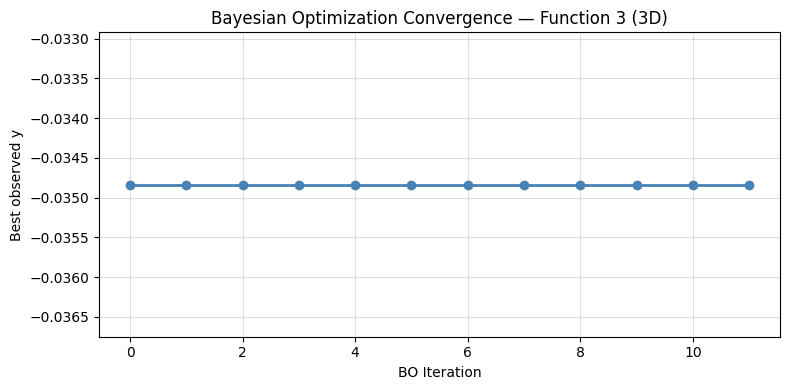

In [17]:
plt.figure(figsize=(8, 4))
plt.plot(range(len(history_best)), history_best, marker="o", linewidth=2, color="steelblue")
plt.xlabel("BO Iteration")
plt.ylabel("Best observed y")
plt.title("Bayesian Optimization Convergence — Function 3 (3D)")
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig("convergence_f3.png", dpi=150)
plt.show()

##Week 2 Recommandation
Same recommendation: switch to EI, but for slightly different reasons.

F2	F3
Dimensions	2D	3D
Initial points	10	15
y range	[-0.07, 0.61]	[-0.399, -0.035]
Current best	0.6112 (near max)	-0.0348 (near max)
Week 1 result	0.036 (worse)	-0.0697 (worse)
ACQ set	ucb	ucb
F3-specific reasoning:

Same pattern as F2 — UCB with κ=2.576 sent you to a worse region again (-0.0697 vs best of -0.0348). Two consecutive UCB suggestions both degraded, which is a signal the aggressive κ is over-exploring.

Current best is already near the top of the range. -0.0348 is essentially the ceiling of what's been observed (-0.399 to -0.035). EI will focus on pushing past this.

3D does warrant more exploration than 2D, but the adaptive xi in EI (starting at 0.05) handles that — you don't need UCB's level of aggression.